Does the scatter we observe in the TFR reduce when we use the NSA axis ratio instead of the SGA?

In [2]:
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from line_fits import hyperfit_line

# Data

In [7]:
# Y1 TFR catalog
# SGA_filename = '/Users/kdouglass/Documents/Research/data/DESI/Y1/DESI-DR1_TF_pv_cat_v15.fits'
# SGA_filename = 'SGA_iron_jointTFR_moduli-v17c_20260630.fits'
SGA_filename='eta_cats/SGA_jura_jointTFR_v5_unweighted.fits'

# NSA
# NSA_filename = '/Users/kdouglass/Documents/Drexel/Research/Data/NSA/nsa_v1_0_1.fits'
NSA_filename = '/pscratch/sd/s/sgmoore1/TF/nsa_v1_0_1.fits'

In [8]:
SGA = Table.read(SGA_filename, format='fits')
NSA = Table.read(NSA_filename, format='fits')

In [9]:
SGA_coords = SkyCoord(ra=SGA['RA']*u.degree, dec=SGA['DEC']*u.degree)
NSA_coords = SkyCoord(ra=NSA['RA']*u.degree, dec=NSA['DEC']*u.degree)

idx, d2d, d3d = SGA_coords.match_to_catalog_sky(NSA_coords)

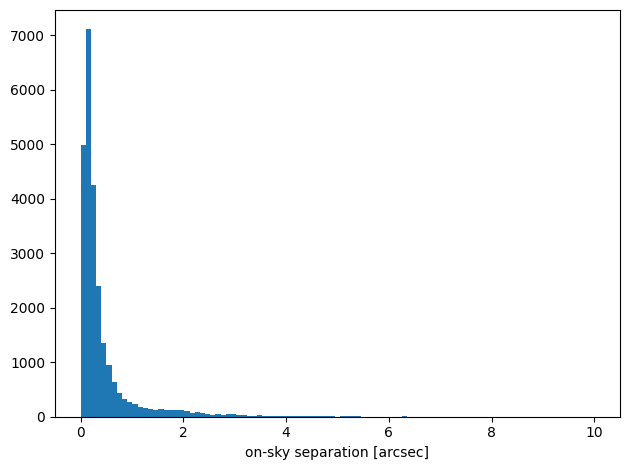

In [10]:
plt.figure(tight_layout=True)

plt.hist(d2d.to('arcsec'), bins=np.linspace(0,10,100)*u.arcsec)

plt.xlabel('on-sky separation [arcsec]');

In [11]:
good_match = d2d.to('arcsec') < 5*u.arcsec

SGA_m = SGA[good_match]
NSA_m = NSA[idx[good_match]]

In [12]:
# Remove any masked rows
bad_rows = NSA_m['ELPETRO_BA'].mask

SGA_matched = SGA_m[~bad_rows]
NSA_matched = NSA_m[~bad_rows]

# Recalculate $V(0.4R_{26})$

Use the NSA axis ratio instead of the SGA-2020

In [13]:
q0 = 0.2

cosi2_NSA = (NSA_matched['ELPETRO_BA']**2 - q0**2)/(1 - q0**2)
cosi2_NSA[cosi2_NSA < 0] = 0

cosi2_SGA = (SGA_matched['BA']**2 - q0**2)/(1 - q0**2)
cosi2_SGA[cosi2_SGA < 0] = 0

sini_NSA = np.sqrt(1 - cosi2_NSA)
sini_SGA = np.sqrt(1 - cosi2_SGA)

In [14]:
SGA_matched['V_0p4R26_NSA'] = SGA_matched['V_0p4R26']*sini_SGA/sini_NSA

# Plot the TFR

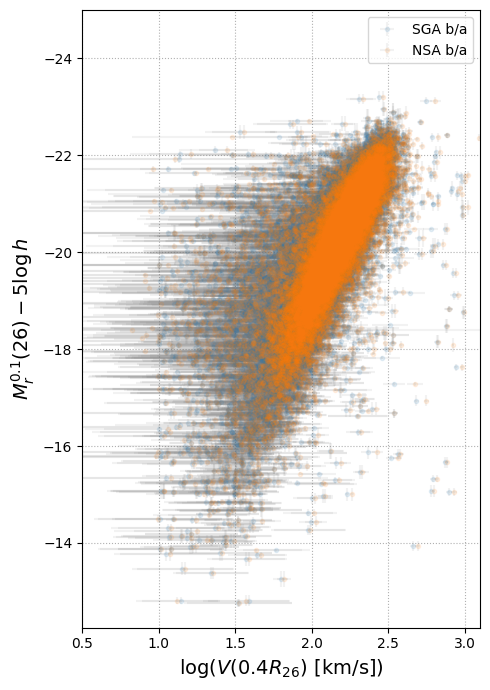

In [15]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_matched['V_0p4R26']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='SGA b/a')

plt.errorbar(np.log10(SGA_matched['V_0p4R26_NSA']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26_NSA'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='NSA b/a')

plt.legend()

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

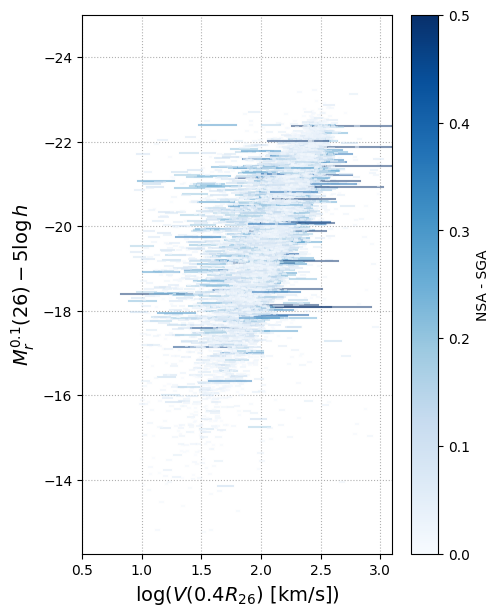

In [16]:
cmap = plt.get_cmap('Blues')

fig, ax = plt.subplots(1,1, figsize=(5,7))

ax.grid(ls=':')

for i in range(len(SGA_matched)):

    plt.plot([np.log10(SGA_matched['V_0p4R26'][i]), np.log10(SGA_matched['V_0p4R26_NSA'][i])], 
             [SGA_matched['R_ABSMAG_SB26'][i], SGA_matched['R_ABSMAG_SB26'][i]], 
             alpha=0.5, 
             c=cmap(np.abs(np.log10(SGA_matched['V_0p4R26_NSA'][i]/SGA_matched['V_0p4R26'][i]))/0.5))

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.5), cmap='Blues'), 
             ax=ax, orientation='vertical', label='NSA - SGA')

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

# Fit a line to both populations to measure the dispersion

In [17]:
logV0_SGA = np.median(np.log10(SGA_matched['V_0p4R26']))

logV_SGA = np.log10(SGA_matched['V_0p4R26']) - logV0_SGA
logV_err_SGA = np.log10(SGA_matched['V_0p4R26_ERR']) / SGA_matched['V_0p4R26']

Mag = SGA_matched['R_ABSMAG_SB26']
Mag_err = SGA_matched['R_ABSMAG_SB26_ERR']

In [18]:
bounds = [[-20, 0]]                 # Bounds on a (slope)
bounds += [(-30, 0)]                # Bounds on B
bounds += [(0,5)]                   # Bounds on sigma

results = hyperfit_line(logV_SGA, Mag, logV_err_SGA, Mag_err, bounds)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

 message: Optimization terminated successfully.
 success: True
     fun: -36845.03936746116
       x: [-2.804e+00 -3.948e-01  1.343e-01]
     nit: 76
    nfev: 3497
     jac: [ 7.845e+00  4.350e+00  1.932e+01]


100%|██████████| 1000/1000 [00:04<00:00, 207.84it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [26.78600149 26.86067032 28.95941341] / 1447.9706706176198


100%|██████████| 1000/1000 [00:04<00:00, 203.88it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [32.87765687 32.93997689 30.38267987] / 1646.9988445580786


100%|██████████| 1000/1000 [00:04<00:00, 205.03it/s]


Niterations/Max Iterations:  3000 / 100000
Integrated ACT/Min Convergence Iterations:  [38.93460174 38.88932011 29.26922567] / 1946.730086803111


100%|██████████| 1000/1000 [00:05<00:00, 198.97it/s]

Niterations/Max Iterations:  4000 / 100000
Integrated ACT/Min Convergence Iterations:  [37.22638794 37.20090236 29.12518792] / 1861.3193968056128


In [19]:
logV0_NSA = np.median(np.log10(SGA_matched['V_0p4R26_NSA']))

logV_NSA = np.log10(SGA_matched['V_0p4R26_NSA']) - logV0_NSA
logV_err_NSA = np.log10(SGA_matched['V_0p4R26_ERR']) / SGA_matched['V_0p4R26_NSA']

/global/homes/s/sgmoore1/.conda/envs/astro-base/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [20]:
bounds = [[-20, 0]]                 # Bounds on a (slope)
bounds += [(-30, 0)]                # Bounds on B
bounds += [(0,5)]                   # Bounds on sigma

results_NSA = hyperfit_line(logV_NSA, Mag, logV_err_NSA, Mag_err, bounds)

a_NSA, b_NSA, sig_tfr_NSA, cov_tfr_NSA, tfr_mcmc_samples_NSA, hf_tfr_NSA = results_NSA

 message: Optimization terminated successfully.
 success: True
     fun: -35883.54744874912
       x: [-2.828e+00 -4.016e-01  1.398e-01]
     nit: 72
    nfev: 3309
     jac: [-1.262e+00  1.621e+00  5.217e+01]


100%|██████████| 1000/1000 [00:05<00:00, 198.82it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [27.91764326 27.79478079 27.18234046] / 1395.8821628277685


100%|██████████| 1000/1000 [00:04<00:00, 205.84it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [35.14712199 35.07048334 33.83389386] / 1757.356099439043


...

Niterations/Max Iterations:  4000 / 100000
Integrated ACT/Min Convergence Iterations:  [38.18393333 38.57666737 43.96991645] / 2198.495822370207


100%|██████████| 1000/1000 [00:05<00:00, 197.40it/s]


Niterations/Max Iterations:  5000 / 100000
Integrated ACT/Min Convergence Iterations:  [34.51307073 34.61180526 49.77815204] / 2488.907602179676


100%|██████████| 1000/1000 [00:05<00:00, 193.75it/s]


Niterations/Max Iterations:  6000 / 100000
Integrated ACT/Min Convergence Iterations:  [34.23475256 34.27095672 48.15662093] / 2407.831046489771


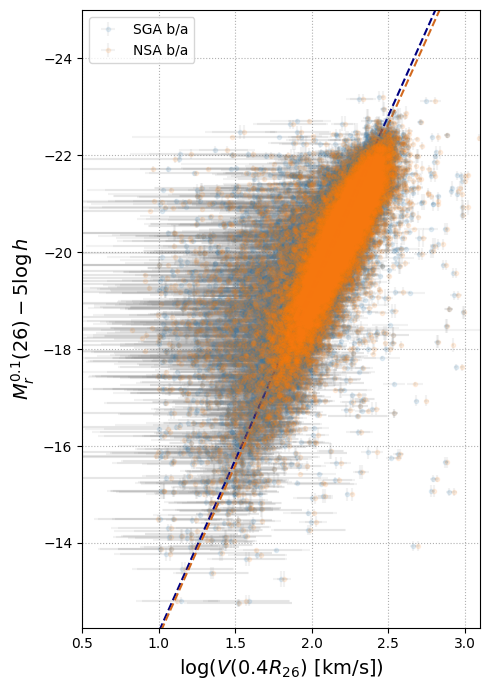

In [21]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_matched['V_0p4R26']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='SGA b/a')

plt.errorbar(np.log10(SGA_matched['V_0p4R26_NSA']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26_NSA'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='NSA b/a')

_logv = np.arange(0, 3, 0.1)

plt.plot(_logv, a*(_logv - logV0_SGA) + b, '--', c='navy')
plt.plot(_logv, a_NSA*(_logv - logV0_NSA) + b_NSA, '--', c='chocolate')

plt.legend()

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

In [22]:
diff_SGA = np.log10(SGA_matched['V_0p4R26']) - ((SGA_matched['R_ABSMAG_SB26'] - b)/a + logV0_SGA)
diff_NSA = np.log10(SGA_matched['V_0p4R26_NSA']) - ((SGA_matched['R_ABSMAG_SB26'] - b_NSA)/a_NSA + logV0_NSA)

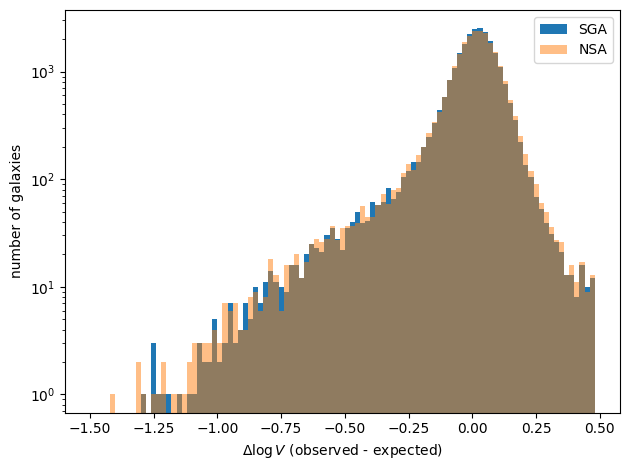

In [23]:
plt.figure(tight_layout=True)

logV_diff_bins = np.arange(-1.5, 0.5, 0.02)

plt.hist(diff_SGA, bins=logV_diff_bins, label='SGA')
plt.hist(diff_NSA, bins=logV_diff_bins, label='NSA', alpha=0.5)

plt.yscale('log')

plt.legend()

plt.xlabel(r'$\Delta \log V$ (observed - expected)')
plt.ylabel('number of galaxies');

In [24]:
print(f'SGA: {np.std(diff_SGA):.2f}')
print(f'NSA: {np.std(diff_NSA):.2f}')

SGA: 0.15
NSA: 0.15


# Compare inclination angles

In [25]:
ba_diff = NSA_matched['ELPETRO_BA'] - SGA_matched['BA']

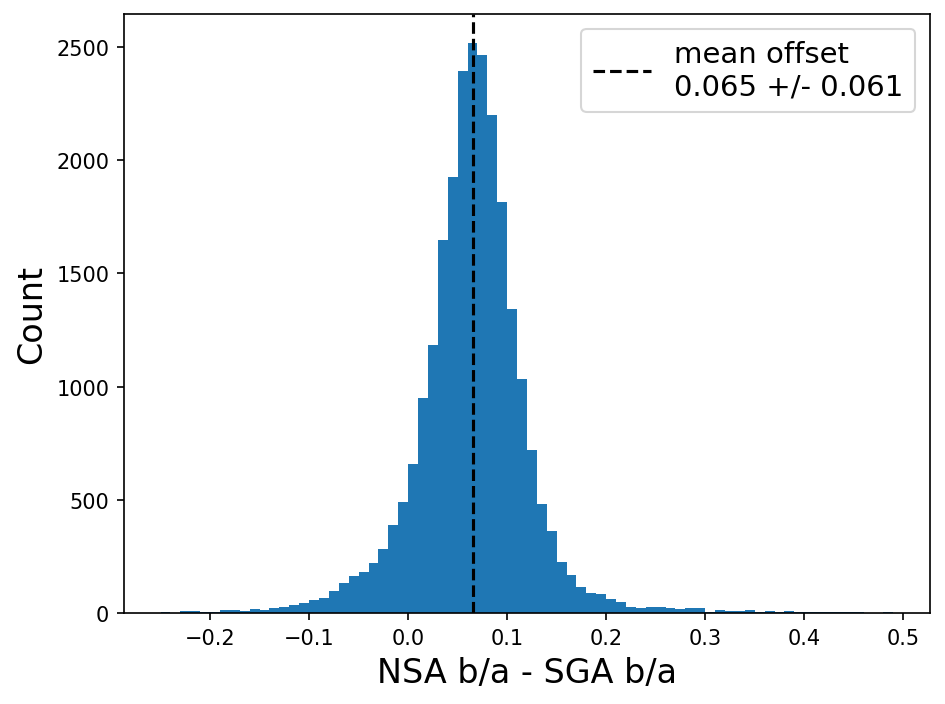

In [42]:
plt.figure(dpi=150, facecolor='none', tight_layout=True)
plt.hist(ba_diff, bins=np.arange(-0.25,0.5,0.01))
plt.xlabel('NSA b/a - SGA b/a', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.axvline(np.mean(ba_diff), color='k',linestyle='dashed',label=f'mean offset \n{np.mean(ba_diff):.3f} +/- {np.std(ba_diff):.3f}')
plt.legend(fontsize=14)